In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

# __Section A - Coding__

In this section, we implement Decision Tree and Random Forest models from scratch for both classification and regression.

**Node Class** - this class represents a single node in the tree.   It stores the node impurity, the prediction, the split rule, and links to the child nodes.  
The same class is used for both classification and regression trees.

In [2]:
# Class for one node in a tree
class Node:
    def __init__(
        self,
        impurity=None,
        num_samples=None,
        prediction=None,
        num_samples_per_class=None,
        feature_index=None,
        threshold=None,
        left=None,
        right=None
    ):
        # impurity at this node
        self.impurity = impurity

        # number of samples in this node
        self.num_samples = num_samples

        # stored prediction:
        self.prediction = prediction

        # class counts (used in classification if needed)
        self.num_samples_per_class = num_samples_per_class

        # split rule
        self.feature_index = feature_index
        self.threshold = threshold

        # children
        self.left = left
        self.right = right

    def is_leaf_node(self):
        return self.left is None and self.right is None

**Gini Impurity** - this function computes the impurity of a node in the classification tree.  
It measures how mixed the class labels are inside the node.  
Formula: **Gini = 1 - Σ(pᵢ²)**.

In [3]:
# Gini impurity calculation function
def calculate_gini(y):
    n = len(y)

    if n == 0:
        return 0.0

    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / n

    return 1.0 - np.sum(probabilities ** 2)

**SSR Calculation** - this function computes the impurity of a node in the regression tree.  
It measures how far the target values are from their mean inside the node.  
Formula: **SSR = Σ(yᵢ - ȳ)²**.

In [4]:
# SSR calculation
def calculate_ssr(y):
    n = len(y)

    if n == 0:
        return 0.0

    mean_value = np.mean(y)
    ssr = np.sum((y - mean_value) ** 2)

    return ssr

**Best Split** - this function searches for the best feature and threshold to split the node.  
It supports both classification and regression, and can also use a random subset of features for random forest.

In [ ]:
#best split search for classification or regression
def find_best_split(X, y, feature_names, min_samples_leaf=5, is_classifier=True, candidate_features=None):
    n_samples, n_features = X.shape

    if n_samples <= 1:
        return None, None, 0.0

    best_gain = 0.0
    best_feature_index = None
    best_threshold = None

    if candidate_features is None:
        candidate_features = list(range(n_features))

    #alphabetical priority
    sorted_feature_indices = sorted(candidate_features, key=lambda i: feature_names[i])

    #parent score
    if is_classifier:
        parent_score = calculate_gini(y)
        classes, y_encoded = np.unique(y, return_inverse=True)
        n_classes = len(classes)
    else:
        parent_score = calculate_ssr(y)

    for feature_index in sorted_feature_indices:
        values = X[:, feature_index]

        # sort once by feature values
        sorted_idx = np.argsort(values)
        x_sorted = values[sorted_idx]
        y_sorted = y[sorted_idx]


        if x_sorted[0] == x_sorted[-1]:
            continue

        if is_classifier:
            # classification: incremental class counts
            _, y_sorted_encoded = np.unique(y_sorted, return_inverse=True)

            left_counts = np.zeros(n_classes, dtype=int)
            right_counts = np.bincount(y_sorted_encoded, minlength=n_classes)

            for i in range(n_samples - 1):
                cls = y_sorted_encoded[i]
                left_counts[cls] += 1
                right_counts[cls] -= 1

                left_size = i + 1
                right_size = n_samples - left_size

                # min_samples_leaf
                if left_size < min_samples_leaf or right_size < min_samples_leaf:
                    continue

                # only split where feature value changes
                if x_sorted[i] == x_sorted[i + 1]:
                    continue

                left_prob = left_counts / left_size
                right_prob = right_counts / right_size

                left_score = 1.0 - np.sum(left_prob ** 2)
                right_score = 1.0 - np.sum(right_prob ** 2)

                child_score = (left_size / n_samples) * left_score + (right_size / n_samples) * right_score
                gain = parent_score - child_score

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = (x_sorted[i] + x_sorted[i + 1]) / 2

        else:
            # egression: incremental sums
            y_sorted = y_sorted.astype(float)

            total_sum = np.sum(y_sorted)
            total_sq_sum = np.sum(y_sorted ** 2)

            left_sum = 0.0
            left_sq_sum = 0.0
            left_size = 0

            for i in range(n_samples - 1):
                yi = y_sorted[i]
                left_size += 1
                right_size = n_samples - left_size

                left_sum += yi
                left_sq_sum += yi ** 2

                if left_size < min_samples_leaf or right_size < min_samples_leaf:
                    continue

                if x_sorted[i] == x_sorted[i + 1]:
                    continue

                right_sum = total_sum - left_sum
                right_sq_sum = total_sq_sum - left_sq_sum

                left_score = left_sq_sum - (left_sum ** 2) / left_size
                right_score = right_sq_sum - (right_sum ** 2) / right_size

                child_score = left_score + right_score
                gain = parent_score - child_score

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = (x_sorted[i] + x_sorted[i + 1]) / 2

    return best_feature_index, best_threshold, best_gain

### __Decision Tree__

**Decision Tree Classifier** - this class implements a classification tree using Gini impurity.  
It predicts the majority class in each node.

In [6]:
class MyDecisionTreeClassifier:
    def __init__(self, min_samples_leaf=5, max_depth=None, max_features=None):
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.max_features = max_features
        self.root = None
        self.feature_names = None

    # train the model: prepare the input data, save the feature names, and start building the tree
    def fit(self, X, y, feature_names=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist() if feature_names is None else feature_names
            X = X.values
        else:
            n_features = X.shape[1]
            name_width = len(str(n_features - 1))
            self.feature_names = feature_names if feature_names is not None else [
               f"feat_{i:0{name_width}d}" for i in range(n_features)
            ]

        # convert y when needed
        if isinstance(y, pd.Series):
            y = y.values
        else:
            y = np.array(y)

        self.root = self._build_tree(X, y, depth=0)
        return self

    # predict the class for each sample in X
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values

        return np.array([self._traverse_tree(x, self.root) for x in X])

    # recursively build the tree
    def _build_tree(self, X, y, depth):
        num_samples = X.shape[0]

        # compute impurity and predicted class
        impurity = calculate_gini(y)
        values, counts = np.unique(y, return_counts=True)
        prediction = values[np.argmax(counts)] if len(y) > 0 else None
        num_samples_per_class = counts

        # stop conditions
        if (
            (self.max_depth is not None and depth >= self.max_depth)
            or num_samples < 2 * self.min_samples_leaf
            or impurity == 0.0
        ):
            return Node(
                impurity=impurity,
                num_samples=num_samples,
                prediction=prediction,
                num_samples_per_class=num_samples_per_class
            )

        # choose candidate features
        n_features = X.shape[1]
        if self.max_features is None:
            candidate_features = None
        else:
            n_selected = min(self.max_features, n_features)
            candidate_features = np.random.choice(n_features, size=n_selected, replace=False)

        # find the best split
        best_feat, best_thresh, best_gain = find_best_split(
            X,
            y,
            self.feature_names,
            self.min_samples_leaf,
            is_classifier=True,
            candidate_features=candidate_features
        )

        # return a leaf if no valid split was found
        if best_feat is None or best_gain <= 0.0:
            return Node(
                impurity=impurity,
                num_samples=num_samples,
                prediction=prediction,
                num_samples_per_class=num_samples_per_class
            )

        # split the data
        left_mask = X[:, best_feat] <= best_thresh
        right_mask = X[:, best_feat] > best_thresh

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(
            impurity=impurity,
            num_samples=num_samples,
            prediction=prediction,
            num_samples_per_class=num_samples_per_class,
            feature_index=best_feat,
            threshold=best_thresh,
            left=left_child,
            right=right_child
        )

    # follow the tree until reaching a leaf
    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.prediction

        if x[node.feature_index] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


**Decision Tree Regressor** - this class implements a regression tree using SSR reduction.  
It predicts the mean target value in each node.

In [7]:
class MyDecisionTreeRegressor:
    def __init__(self, min_samples_leaf=5, max_depth=None, max_features=None):
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.max_features = max_features
        self.root = None
        self.feature_names = None

    # train the model: prepare the input data, save the feature names, and start building the tree
    def fit(self, X, y, feature_names=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist() if feature_names is None else feature_names
            X = X.values
        else:
            n_features = X.shape[1]
            name_width = len(str(n_features - 1))
            self.feature_names = feature_names if feature_names is not None else [
               f"feat_{i:0{name_width}d}" for i in range(n_features)
            ]           

        # convert y when needed
        if isinstance(y, pd.Series):
            y = y.values
        else:
            y = np.array(y)

        self.root = self._build_tree(X, y, depth=0)
        return self

    # predict the target value for each sample in X
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values

        return np.array([self._traverse_tree(x, self.root) for x in X])

    # recursively build the tree
    def _build_tree(self, X, y, depth):
        num_samples = X.shape[0]

        # compute impurity and predicted value
        impurity = calculate_ssr(y)
        prediction = np.mean(y) if len(y) > 0 else None

        # stop conditions
        if (
            (self.max_depth is not None and depth >= self.max_depth)
            or num_samples < 2 * self.min_samples_leaf
            or impurity == 0.0
        ):
            return Node(
                impurity=impurity,
                num_samples=num_samples,
                prediction=prediction,
                num_samples_per_class=None
            )

        # choose candidate features
        n_features = X.shape[1]
        if self.max_features is None:
            candidate_features = None
        else:
            n_selected = min(self.max_features, n_features)
            candidate_features = np.random.choice(n_features, size=n_selected, replace=False)

        # find the best split
        best_feat, best_thresh, best_gain = find_best_split(
            X,
            y,
            self.feature_names,
            self.min_samples_leaf,
            is_classifier=False,
            candidate_features=candidate_features
        )

        # return a leaf if no valid split was found
        if best_feat is None or best_gain <= 0.0:
            return Node(
                impurity=impurity,
                num_samples=num_samples,
                prediction=prediction,
                num_samples_per_class=None
            )

        # split the data
        left_mask = X[:, best_feat] <= best_thresh
        right_mask = X[:, best_feat] > best_thresh

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(
            impurity=impurity,
            num_samples=num_samples,
            prediction=prediction,
            num_samples_per_class=None,
            feature_index=best_feat,
            threshold=best_thresh,
            left=left_child,
            right=right_child
        )

    # follow the tree until reaching a leaf
    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.prediction

        if x[node.feature_index] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


### __Random Forest__

**Random Forest Helper Functions** - these functions support the random forest models.  
They create bootstrap samples and combine predictions from multiple trees.

In [8]:
# create a bootstrap sample
def bootstrap_sample(X, y):
    n_samples = X.shape[0]
    indices = np.random.choice(n_samples, size=n_samples, replace=True)

    X_sample = X.iloc[indices] if isinstance(X, pd.DataFrame) else X[indices]
    y_sample = y.iloc[indices] if isinstance(y, pd.Series) else y[indices]

    return X_sample, y_sample


# return the most common class
def majority_vote(predictions):
    values, counts = np.unique(predictions, return_counts=True)
    return values[np.argmax(counts)]


# return the average prediction
def average_predictions(predictions):
    return np.mean(predictions)

**Random Forest Classifier** - this class implements a random forest for classification.  
It trains multiple decision trees on bootstrap samples and combines their predictions by majority voting.

In [9]:
class MyRandomForestClassifier:
    def __init__(self, n_estimators=10, min_samples_leaf=5, max_depth=None, max_features=None):
        self.n_estimators = n_estimators
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []

    # train the model: create bootstrap samples and train multiple trees
    def fit(self, X, y):
        self.trees = []

        n_features = X.shape[1]
        max_features = self.max_features if self.max_features is not None else max(1, int(np.sqrt(n_features)))

        for _ in range(self.n_estimators):
            X_sample, y_sample = bootstrap_sample(X, y)

            tree = MyDecisionTreeClassifier(
                min_samples_leaf=self.min_samples_leaf,
                max_depth=self.max_depth,
                max_features=max_features
            )

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    # predict the class for each sample in X
    def predict(self, X):
        all_predictions = []

        for tree in self.trees:
            all_predictions.append(tree.predict(X))

        all_predictions = np.array(all_predictions)

        final_predictions = [
            majority_vote(all_predictions[:, i])
            for i in range(all_predictions.shape[1])
        ]

        return np.array(final_predictions)

    # compute classification accuracy
    def score(self, X, y):
        y_pred = self.predict(X)

        if isinstance(y, pd.Series):
            y = y.values
        else:
            y = np.array(y)

        return np.mean(y_pred == y)


**Random Forest Regressor** - this class implements a random forest for regression.  
It trains multiple regression trees on bootstrap samples and combines their predictions by averaging.

In [10]:
class MyRandomForestRegressor:
    def __init__(self, n_estimators=10, min_samples_leaf=5, max_depth=None, max_features=None):
        self.n_estimators = n_estimators
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []

    # train the model: create bootstrap samples and train multiple trees
    def fit(self, X, y):
        self.trees = []

        n_features = X.shape[1]
        max_features = self.max_features if self.max_features is not None else max(1, n_features // 3)

        for _ in range(self.n_estimators):
            X_sample, y_sample = bootstrap_sample(X, y)

            tree = MyDecisionTreeRegressor(
                min_samples_leaf=self.min_samples_leaf,
                max_depth=self.max_depth,
                max_features=max_features
            )

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    # predict the target value for each sample in X
    def predict(self, X):
        all_predictions = []

        for tree in self.trees:
            all_predictions.append(tree.predict(X))

        all_predictions = np.array(all_predictions)

        final_predictions = [
            average_predictions(all_predictions[:, i])
            for i in range(all_predictions.shape[1])
        ]

        return np.array(final_predictions)

    # compute regression mse
    def score(self, X, y):
        y_pred = self.predict(X)

        if isinstance(y, pd.Series):
            y = y.values
        else:
            y = np.array(y)

        return np.mean((y - y_pred) ** 2)

# __Section B - Data Preparation__
### __Data visualization__ 
In this part, we explore the distributions of the target and key variables.  
The selected plots help us inspect outliers, artifacts, and the relationship between vehicle condition and price.

-> visualization setup: import the data from the csv file, define colors and style

In [11]:
# load the dataset
df = pd.read_csv("vehicle_price_prediction.csv")

# plotting style
sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 8


print("dataset shape:", df.shape)
display(df.head())

df.info()

dataset shape: (1000000, 20)


,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,NaN,Dealer,Excellent,EX,9,20433.666667,0.040054,7208.52
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,0.039921,6911.81
2,Subaru,Crosstrek,2016,103199,188,Automatic,Diesel,AWD,Sedan,Silver,Beige,5,NaN,Dealer,Excellent,Touring,9,11466.555556,0.040230,11915.63
3,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,NaN,Private,Good,Base,9,13209.888889,0.039847,25984.79
4,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,0.039627,8151.30


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   make              1000000 non-null  object 
 1   model             1000000 non-null  object 
 2   year              1000000 non-null  int64  
 3   mileage           1000000 non-null  int64  
 4   engine_hp         1000000 non-null  int64  
 5   transmission      1000000 non-null  object 
 6   fuel_type         1000000 non-null  object 
 7   drivetrain        1000000 non-null  object 
 8   body_type         1000000 non-null  object 
 9   exterior_color    1000000 non-null  object 
 10  interior_color    1000000 non-null  object 
 11  owner_count       1000000 non-null  int64  
 12  accident_history  249867 non-null   object 
 13  seller_type       1000000 non-null  object 
 14  condition         1000000 non-null  object 
 15  trim              1000000 non-null  object 
 16  v

 - **vehicle price distribution** :we chose a histogram because price is a continuous variable and the main target for the regression task.
This plot helps us understand the overall distribution of vehicle prices. 
In our dataset, prices are right-skewed: most vehicles are concentrated in the lower and middle price ranges, while a smaller number of expensive vehicles create a long tail. The fact that the mean is higher than the median supports this pattern and suggests the presence of high-price outliers.

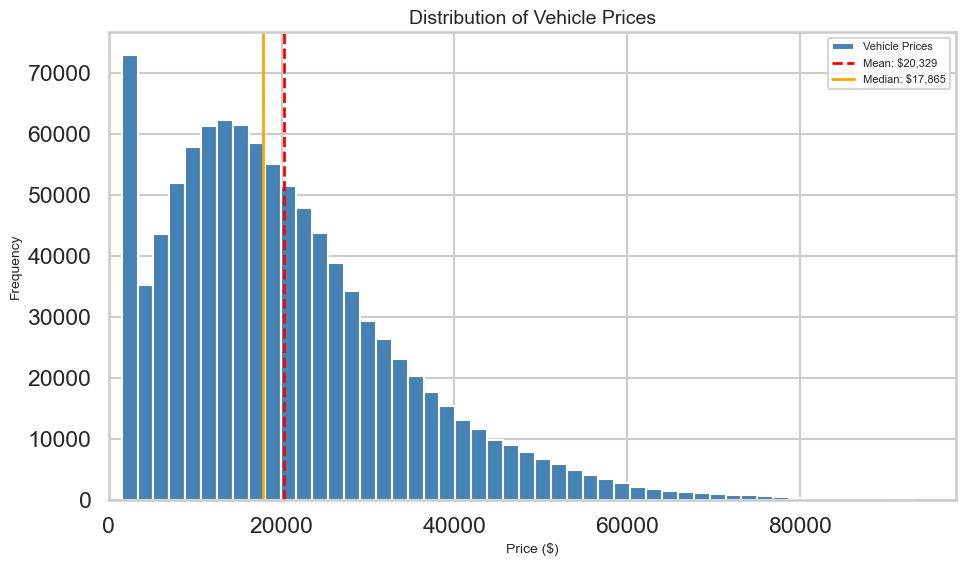

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df["price"], bins=50, color="steelblue", edgecolor="white", label="Vehicle Prices")

# calculation and adding of  the mean and median
mean_price = df["price"].mean()
median_price = df["price"].median()
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2, label=f'Mean: ${mean_price:,.0f}')
plt.axvline(median_price, color='orange', linestyle='solid', linewidth=2, label=f'Median: ${median_price:,.0f}')

plt.title("Distribution of Vehicle Prices", fontsize=14)
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.xlim(left=0)

plt.legend()
plt.tight_layout()
plt.show()

* **correlation heatmap of numerical features** : we chose a heatmap because it is useful for summarizing the relationships between several numerical variables at once.
In our dataset, the heatmap shows that price is positively related to year and engine_hp, and negatively related to mileage and vehicle_age. It also highlights that year and vehicle_age are almost perfectly inversely correlated, which is expected because they describe opposite aspects of the same characteristic.

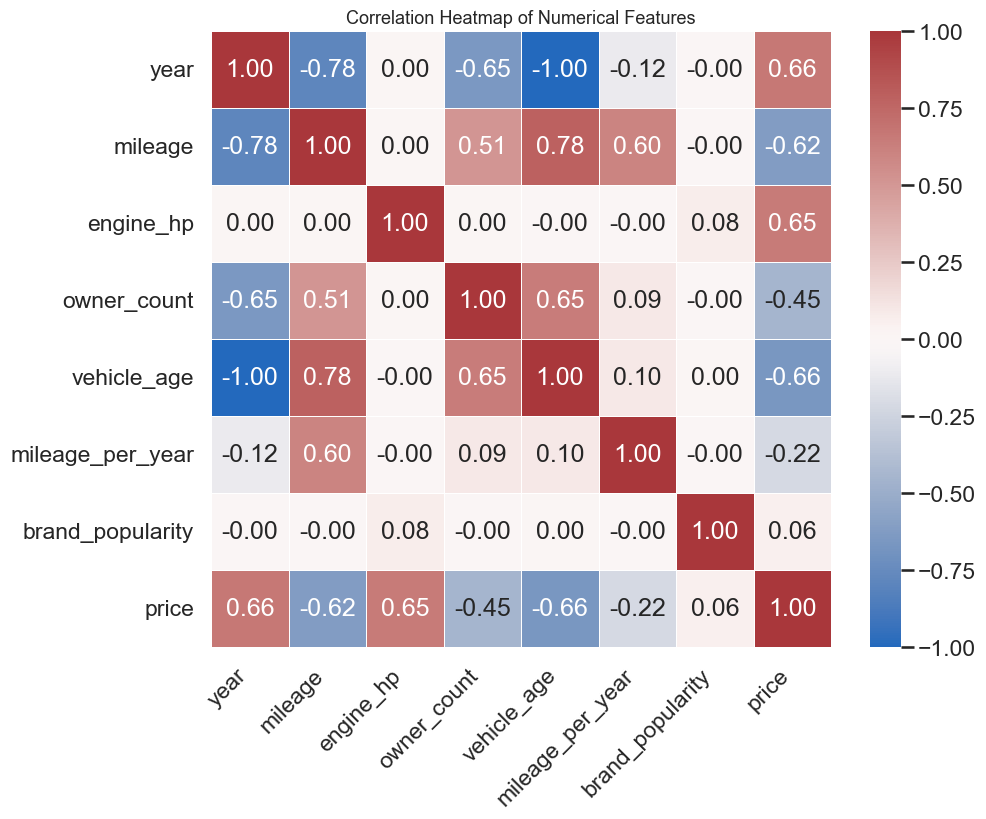

In [13]:
selected_numeric = [
    "year",
    "mileage",
    "engine_hp",
    "owner_count",
    "vehicle_age",
    "mileage_per_year",
    "brand_popularity",
    "price"
]

plt.figure(figsize=(10, 8))
corr_matrix = df[selected_numeric].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

* **vehicle characteristics across price groups** - we chose line plots because they are useful for showing how numerical features change across ordered price ranges.
In our dataset, the graphs show a clear pattern: as price increases, median mileage and vehicle_age decrease, while median engine_hp increases. This is consistent with the correlation heatmap, where price was negatively related to mileage and vehicle_age, and positively related to engine_hp. Together, these plots strengthen the conclusion that more expensive vehicles tend to be newer, less used, and more powerful.

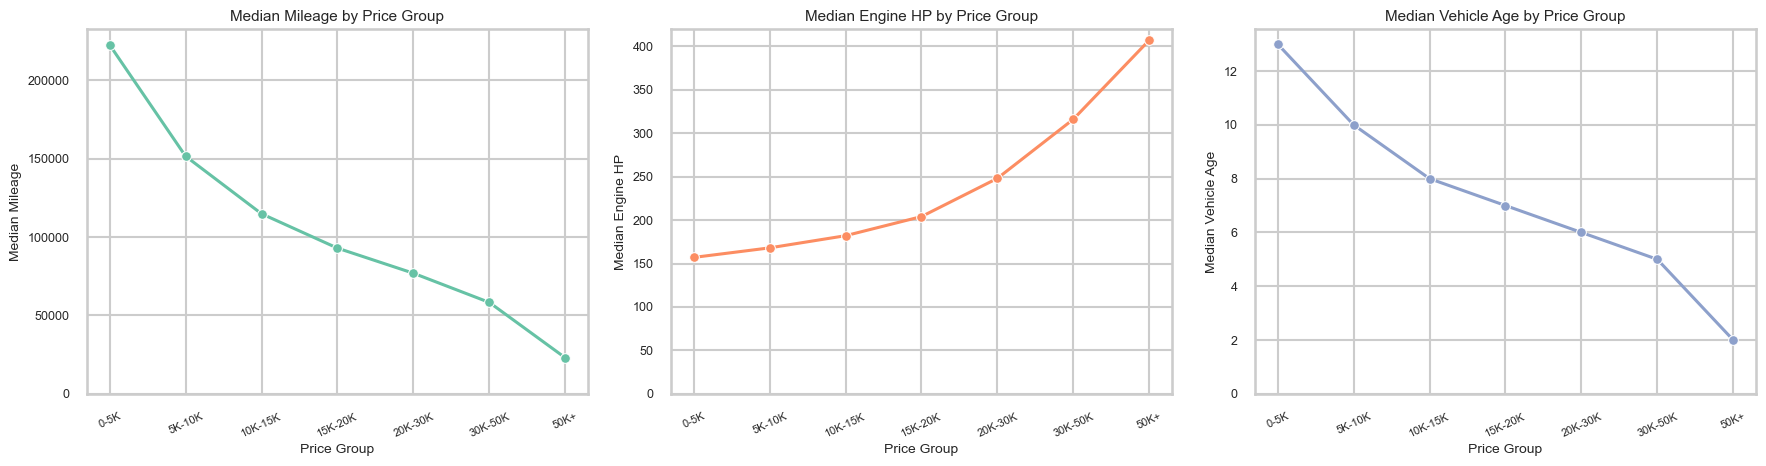

In [14]:
price_bins = [0, 5000, 10000, 15000, 20000, 30000, 50000, float("inf")]
price_labels = ["0-5K", "5K-10K", "10K-15K", "15K-20K", "20K-30K", "30K-50K", "50K+"]

df["price_group"] = pd.cut(
    df["price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

price_summary = (
    df.groupby("price_group", observed=False)[["mileage", "engine_hp", "vehicle_age"]]
    .median()
    .reset_index()
)

set2_colors = sns.color_palette("Set2")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)

sns.lineplot(
    data=price_summary,
    x="price_group",
    y="mileage",
    marker="o",
    color=set2_colors[0],
    linewidth=2.2,
    markersize=7,
    ax=axes[0]
)
axes[0].set_title("Median Mileage by Price Group", fontsize=11)
axes[0].set_xlabel("Price Group", fontsize=10)
axes[0].set_ylabel("Median Mileage", fontsize=10)
axes[0].tick_params(axis="x", labelsize=8, rotation=25)
axes[0].tick_params(axis="y", labelsize=9)
axes[0].set_ylim(bottom=0)

sns.lineplot(
    data=price_summary,
    x="price_group",
    y="engine_hp",
    marker="o",
    color=set2_colors[1],
    linewidth=2.2,
    markersize=7,
    ax=axes[1]
)
axes[1].set_title("Median Engine HP by Price Group", fontsize=11)
axes[1].set_xlabel("Price Group", fontsize=10)
axes[1].set_ylabel("Median Engine HP", fontsize=10)
axes[1].tick_params(axis="x", labelsize=8, rotation=25)
axes[1].tick_params(axis="y", labelsize=9)
axes[1].set_ylim(bottom=0)

sns.lineplot(
    data=price_summary,
    x="price_group",
    y="vehicle_age",
    marker="o",
    color=set2_colors[2],
    linewidth=2.2,
    markersize=7,
    ax=axes[2]
)
axes[2].set_title("Median Vehicle Age by Price Group", fontsize=11)
axes[2].set_xlabel("Price Group", fontsize=10)
axes[2].set_ylabel("Median Vehicle Age", fontsize=10)
axes[2].tick_params(axis="x", labelsize=8, rotation=25)
axes[2].tick_params(axis="y", labelsize=9)
axes[2].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

* **distribution of vehicle condition** : we chose a bar chart because condition is a categorical variable and the target for the classification task.
This plot helps compare the frequency of each condition category. In our dataset, Good is the most common class, followed by Excellent, while Fair appears much less often. This suggests a noticeable class imbalance, which may affect the classification stage later on.

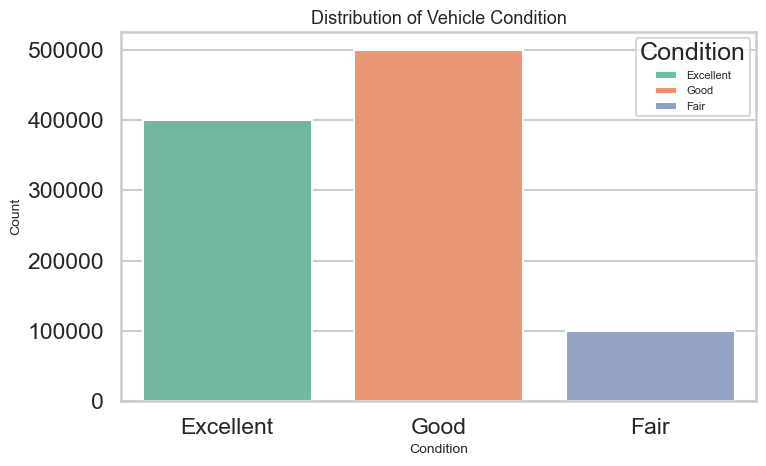

In [15]:
from matplotlib.patches import Patch   #patch is used to create custom legend boxes with specific colors and labels.

colors = sns.color_palette("Set2", 3)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="condition",
    hue="condition",
    order=["Excellent", "Good", "Fair"],
    hue_order=["Excellent", "Good", "Fair"],
    palette=colors,
    legend=False
)

plt.title("Distribution of Vehicle Condition")
plt.xlabel("Condition")
plt.ylabel("Count")

legend_elements = [
    Patch(facecolor=colors[0], label="Excellent"),
    Patch(facecolor=colors[1], label="Good"),
    Patch(facecolor=colors[2], label="Fair")
]

plt.legend(handles=legend_elements, title="Condition", loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

* **numerical features by vehicle condition** : we chose boxplots because they allow us to compare the center, spread, and outliers of several numerical features across the condition categories.
This comparison is useful for checking whether condition is visually separated by variables such as mileage, vehicle_age, engine_hp, and owner_count. In our dataset, all four plots show very similar medians and interquartile ranges across Excellent, Good, and Fair, with substantial overlap between the groups. This suggests that these numerical features do not provide strong visual separation for vehicle condition, and that condition appears relatively stable across the examined variables.

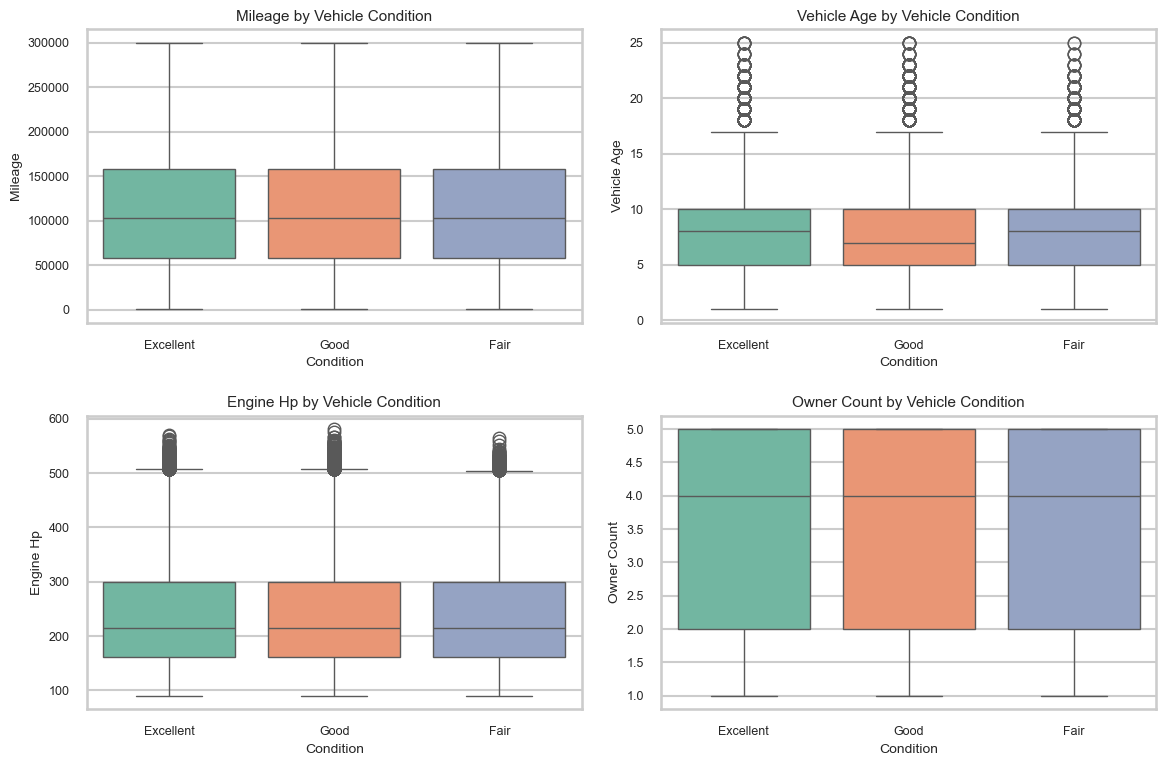

In [16]:
features_to_check = ["mileage", "vehicle_age", "engine_hp", "owner_count"]

set2_colors = sns.color_palette("Set2", 3)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_check):
    sns.boxplot(
        data=df,
        x="condition",
        y=feature,
        hue="condition",
        order=["Excellent", "Good", "Fair"],
        hue_order=["Excellent", "Good", "Fair"],
        palette=set2_colors,
        legend=False,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{feature.replace('_', ' ').title()} by Vehicle Condition", fontsize=11)
    axes[i].set_xlabel("Condition", fontsize=10)
    axes[i].set_ylabel(feature.replace("_", " ").title(), fontsize=10)
    axes[i].tick_params(axis="x", labelsize=9)
    axes[i].tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.show()

### __Data preparation__

In this part, we prepare the dataset for the later modeling stages.
The main goal is to clean the data, handle missing values if needed, and define the variables in a format suitable for analysis and prediction.

In [17]:
#check missing values in each column
missing_values = df.isnull().sum()
print("Missing values before handling:")
print(missing_values)

Missing values before handling:
make                     0
model                    0
year                     0
mileage                  0
engine_hp                0
transmission             0
fuel_type                0
drivetrain               0
body_type                0
exterior_color           0
interior_color           0
owner_count              0
accident_history    750133
seller_type              0
condition                0
trim                     0
vehicle_age              0
mileage_per_year         0
brand_popularity         0
price                    0
price_group              0
dtype: int64


During data preparation, we checked the dataset for missing values and found that they appeared only in the `accident_history` feature.
Because this is a categorical variable and the number of missing entries is large, we did not remove the affected rows, in order to avoid losing a substantial part of the dataset. Instead, we replaced the missing values with `"Unknown"`, so the missing information could be preserved as a separate category for later analysis and modeling.


In [18]:
# fill missing values
df["accident_history"] = df["accident_history"].fillna("Unknown")

# check missing values after handling
print("\nMissing values after handling:")
print(df["accident_history"].isnull().sum())


Missing values after handling:
0


### __Outlier Analysis__

In this part, we manually inspect the price and mileage features and use a statistical method to detect extreme values.
Since both variables are continuous and may contain unusually high observations, we apply the IQR method to identify potential outliers while keeping the analysis simple and interpretable.

* **price** -  IQR method to identify potential outliers

In [19]:
Q1_price = df["price"].quantile(0.25)
Q3_price = df["price"].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

price_outliers = df[(df["price"] < lower_bound_price) | (df["price"] > upper_bound_price)]

print(f"Q1 (25th percentile): {Q1_price:.2f}")
print(f"Q3 (75th percentile): {Q3_price:.2f}")
print(f"IQR: {IQR_price:.2f}")
print(f"Lower bound: {lower_bound_price:.2f}")
print(f"Upper bound: {upper_bound_price:.2f}")
print(f"Number of price outliers: {len(price_outliers)}")
print(f"Percentage of price outliers: {len(price_outliers) / len(df) * 100:.2f}%")

Q1 (25th percentile): 10324.53
Q3 (75th percentile): 27601.40
IQR: 17276.88
Lower bound: -15590.78
Upper bound: 53516.71
Number of price outliers: 25524
Percentage of price outliers: 2.55%


The IQR method identified several outliers, mainly on the upper side of the distribution.We did not remove the detected price outliers, because they likely represent real differences in vehicle value rather than errors.
Instead, we kept them in the dataset and noted their presence for later modeling.

We chose a boxplot because it clearly shows the spread of price and highlights potential outliers.

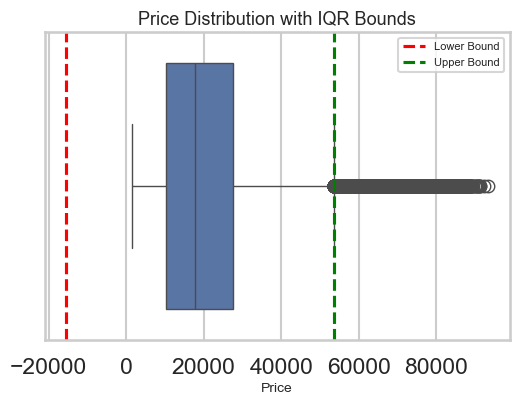

In [20]:
# boxplot with IQR bounds for Price
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])

plt.axvline(lower_bound_price, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound_price, color='green', linestyle='--', label='Upper Bound')

plt.title("Price Distribution with IQR Bounds")
plt.xlabel("Price")
plt.legend()

plt.show()

* **mileage** -  IQR method to identify potential outliers

In [21]:
# Outlier Analysis - Mileage (IQR)

Q1_mileage = df["mileage"].quantile(0.25)
Q3_mileage = df["mileage"].quantile(0.75)
IQR_mileage = Q3_mileage - Q1_mileage

lower_bound_mileage = Q1_mileage - 1.5 * IQR_mileage
upper_bound_mileage = Q3_mileage + 1.5 * IQR_mileage

mileage_outliers = df[(df["mileage"] < lower_bound_mileage) | (df["mileage"] > upper_bound_mileage)]

print(f"Q1 (25th percentile): {Q1_mileage:.2f}")
print(f"Q3 (75th percentile): {Q3_mileage:.2f}")
print(f"IQR: {IQR_mileage:.2f}")
print(f"Lower bound: {lower_bound_mileage:.2f}")
print(f"Upper bound: {upper_bound_mileage:.2f}")
print(f"Number of mileage outliers: {len(mileage_outliers)}")
print(f"Percentage of mileage outliers: {len(mileage_outliers) / len(df) * 100:.2f}%")

Q1 (25th percentile): 57654.00
Q3 (75th percentile): 157865.00
IQR: 100211.00
Lower bound: -92662.50
Upper bound: 308181.50
Number of mileage outliers: 0
Percentage of mileage outliers: 0.00%


No mileage outliers were detected, since all values fall within the calculated IQR bounds. Although some vehicles have very high mileage (e.g., around 300,000 km), these values appear often enough in the dataset to be considered part of the normal distribution rather than true anomalies.
This suggests that these values are part of the natural distribution or may reflect repeated patterns in the data, rather than true anomalies.

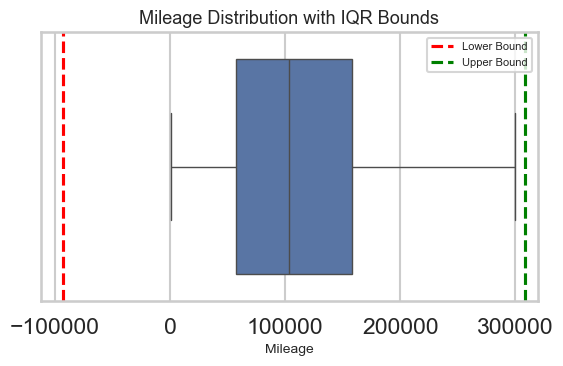

In [22]:
# Boxplot with IQR bounds for Mileage

Q1_mileage = df["mileage"].quantile(0.25)
Q3_mileage = df["mileage"].quantile(0.75)
IQR_mileage = Q3_mileage - Q1_mileage

lower_bound_mileage = Q1_mileage - 1.5 * IQR_mileage
upper_bound_mileage = Q3_mileage + 1.5 * IQR_mileage

plt.figure(figsize=(6, 4))
sns.boxplot(x=df["mileage"])

plt.axvline(lower_bound_mileage, color="red", linestyle="--", label="Lower Bound")
plt.axvline(upper_bound_mileage, color="green", linestyle="--", label="Upper Bound")

plt.title("Mileage Distribution with IQR Bounds")
plt.xlabel("Mileage")
plt.legend()
plt.tight_layout()
plt.show()

### __Artifact Analysis__

In this part, we investigate unusual patterns in the data that may come from the data collection process rather than from real vehicle behavior.
Specifically, we examine the floor effect in price and the clumping pattern in mileage, and decide whether these values should be treated as true outliers or as data-acquisition artifacts.

In [23]:
# Floor effect in price
top_price_counts = df["price"].value_counts().head(10)
print("Most frequent price values:")
print(top_price_counts)

price_1500_count = (df["price"] == 1500).sum()
percentage_1500 = price_1500_count / len(df) * 100

print(f"\nNumber of $1,500 values: {price_1500_count}")
print(f"Percentage: {percentage_1500:.2f}%")

Most frequent price values:
price
1500.00     46984
12675.51        6
11073.96        6
23548.84        6
16100.20        6
13893.71        5
19782.94        5
11951.19        5
17086.60        5
16206.10        5
Name: count, dtype: int64

Number of $1,500 values: 46984
Percentage: 4.70%


The price feature shows a clear floor effect, with approximately 5% of the observations taking the exact value 1500.
Such a concentration at one specific lower-bound value is unlikely to reflect natural market behavior, where prices would normally vary more continuously. Instead, it suggests a data-acquisition artifact, such as a minimum allowed value, rounding rule, or placeholder introduced during collection or preprocessing.

For this reason, these observations were treated as artifacts rather than true outliers. However, we chose to keep them in the dataset, because the value itself is still plausible for low-priced vehicles, and removing all of these records could artificially change the lower end of the price distribution. Therefore, retaining them preserves the original data structure while acknowledging that this cluster may not fully represent real market prices.

In [24]:
# Clumps in mileage
top_mileage_counts = df["mileage"].value_counts().head(10)
print("Most frequent mileage values:")
print(top_mileage_counts)

#  the clump at 300,000 km
mileage_300k_count = (df["mileage"] == 300000).sum()
percentage_300k = mileage_300k_count / len(df) * 100

print(f"\nNumber of 300,000 mileage values: {mileage_300k_count}")
print(f"Percentage: {percentage_300k:.2f}%")

Most frequent mileage values:
mileage
300000    18534
500        4016
81824        21
70809        17
62211        17
75418        17
1346         17
78872        17
994          17
2443         17
Name: count, dtype: int64

Number of 300,000 mileage values: 18534
Percentage: 1.85%


In the mileage feature, we observed clear clumping at specific values, especially 300,000 km, which appears 18,534 times and accounts for about 1.85% of the dataset.
Such a large repetition at an exact round number is unlikely to reflect naturally measured mileage values, which would usually vary more continuously. This pattern is more consistent with a data-acquisition artifact, such as rounding, top-coding, reporting conventions, or system-imposed limits for very high mileage.
For this reason, these repeated values were not treated as true outliers. Instead, they were interpreted as artifacts of the recording process. We chose to keep them in the dataset, because they still represent plausible high-mileage vehicles, and removing them could distort the upper range of the mileage distribution. This distinction is important, since not every unusual pattern in the data reflects an error; some patterns arise from the way the data was collected or encoded.








### __Justification__

We defined outliers using the **IQR rule**, where values below **Q1 − 1.5·IQR** or above **Q3 + 1.5·IQR** were flagged as extreme, because this is a standard and robust method for skewed variables such as `price` and `mileage`. 

Using this threshold, outliers were detected in "price" but not in "mileage". 

owever, we chose not to remove these values, since the extreme prices likely reflect real market variation, while the floor effect in "price" and the clumps in "mileage" appear to be data-acquisition artifacts rather than true errors. 

As a result, no entries were removed, and the overall data distribution remained unchanged.

# __Section C - Implementation & Complexity__
In this section, we train the four models built from scratch in **Section A** and evaluate them on both tasks: **classification** for `condition` and **regression** for `price`.  
The goal is to compare their predictive performance and analyze their computational complexity during training and prediction.

### __Data Preparation__

Before training the model, we convert the categorical variables into numerical form.  
The target variable `condition` was encoded into numeric labels, and the categorical input features were transformed using one-hot encoding.  

In [35]:
df_cls = df.copy()
X = df_cls.drop(columns=["condition", "price"])   # remove both target columns
y = df_cls["condition"]

# Convert target labels to numerical values manually
condition_mapping = {
    "Excellent": 0,
    "Good": 1,
    "Fair": 2
}
y = y.map(condition_mapping)

# Convert categorical input features to numerical form
X = pd.get_dummies(X, drop_first=True)

print("Encoded feature matrix shape:", X.shape)
print("Target mapping:", condition_mapping)
print("Number of encoded features:", X.shape[1])

Encoded feature matrix shape: (1000000, 168)
Target mapping: {'Excellent': 0, 'Good': 1, 'Fair': 2}
Number of encoded features: 168


The dataset splited into training and test sets according to the provided indices.

In [36]:
X_train = X.iloc[0:70001]
X_val   = X.iloc[70001:85001]
X_test  = X.iloc[85001:]

y_train = y.iloc[0:70001]
y_val   = y.iloc[70001:85001]
y_test  = y.iloc[85001:]

print("Dataset shapes after splitting:")
print(f"Train set: X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation set: X = {X_val.shape}, y = {y_val.shape}")
print(f"Test set: X = {X_test.shape}, y = {y_test.shape}")

Dataset shapes after splitting:
Train set: X = (70001, 168), y = (70001,)
Validation set: X = (15000, 168), y = (15000,)
Test set: X = (914999, 168), y = (914999,)


Save metrics for the comparison 

In [ ]:
metrics = {}

## Decision Tree Classifier 
We used the training set to fit candidate models and the validation set to choose the best parameters, such as `max_depth`.  
After selecting the final model, we retrained it on the combined training and validation data, and used the test set only for the final evaluation.

In [41]:
# Find the best depth using the validation set
best_depth = None
best_val_accuracy = 0

for depth in range(1, 11):
    dt_classifier = MyDecisionTreeClassifier(
        min_samples_leaf=5,
        max_depth=depth
    )
    
    dt_classifier.fit(X_train, y_train)
    val_predictions = dt_classifier.predict(X_val)
    val_accuracy = np.mean(val_predictions == y_val)
    
    print(f"Depth {depth}: validation accuracy = {val_accuracy:.4f}")
    
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_depth = depth

print("\nBest depth:", best_depth)
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

# Combine train and validation sets
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

# Train the final model
final_dt_classifier = MyDecisionTreeClassifier(
    min_samples_leaf=5,
    max_depth=best_depth
)

start_time = time.time()
final_dt_classifier.fit(X_train_val, y_train_val)
test_predictions = final_dt_classifier.predict(X_test)
end_time = time.time()

# Evaluate the final model
test_accuracy = np.mean(test_predictions == y_test)
run_time = end_time - start_time

print(f"\nTest accuracy: {test_accuracy:.4f}")
print(f"Runtime: {run_time:.4f} seconds")

# Store results
metrics["DecisionTreeClassifier"] = {
    "accuracy": test_accuracy,
    "time": run_time,
    "best_depth": best_depth
}

Depth 1: validation accuracy = 0.5009
Depth 2: validation accuracy = 0.5009
Depth 3: validation accuracy = 0.4991


KeyboardInterrupt: 